In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import mode


In [3]:
print("Starting Wine Dataset Clustering...\n")

wine = load_wine()
data = wine.data
true_labels = wine.target
feature_names = wine.feature_names

wine_df = pd.DataFrame(data, columns=feature_names)
wine_df["true_label"] = true_labels

print("Dataset Overview:")
print(f"Samples: {data.shape[0]}")
print(f"Features: {data.shape[1]}")
print(wine_df.head())


Starting Wine Dataset Clustering...

Dataset Overview:
Samples: 178
Features: 13
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82         

In [4]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)


In [5]:
print("\nCalculating inertia values (Elbow Method)...")

k_range = range(1, 11)
inertia_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(data_scaled)
    inertia_scores.append(km.inertia_)
    print(f"k={k}, inertia={km.inertia_:.2f}")



Calculating inertia values (Elbow Method)...
k=1, inertia=2314.00
k=2, inertia=1658.76
k=3, inertia=1277.93
k=4, inertia=1175.43
k=5, inertia=1109.51
k=6, inertia=1046.00
k=7, inertia=981.60
k=8, inertia=935.20
k=9, inertia=889.89
k=10, inertia=845.90


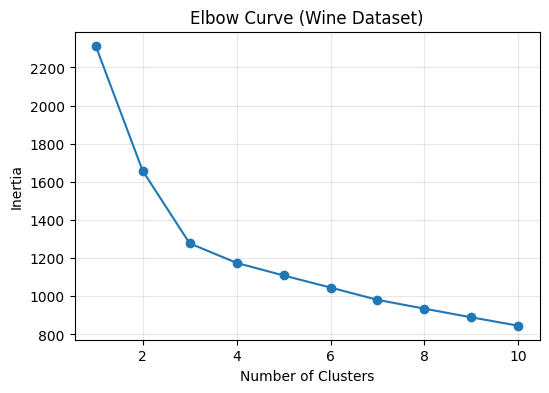

In [6]:
plt.figure(figsize=(6, 4))
plt.plot(k_range, inertia_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Curve (Wine Dataset)")
plt.grid(alpha=0.3)
plt.show()


In [7]:
k_opt = 3


In [8]:
print("\nRunning K-Means with k=3")

kmeans_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
predicted_clusters = kmeans_final.fit_predict(data_scaled)

wine_df["cluster"] = predicted_clusters

print("\nCluster Distribution:")
print(wine_df["cluster"].value_counts().sort_index())



Running K-Means with k=3

Cluster Distribution:
cluster
0    65
1    51
2    62
Name: count, dtype: int64


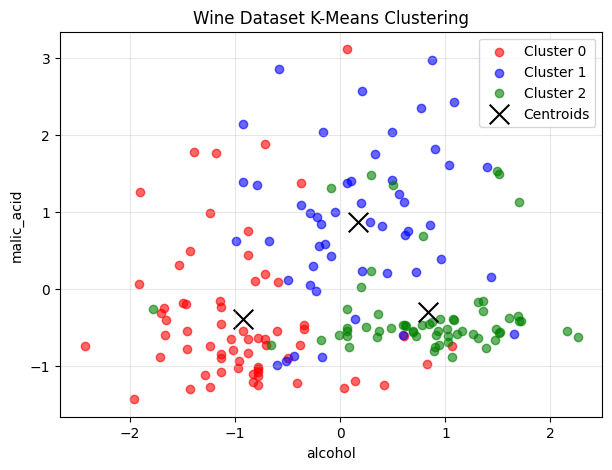

In [9]:
plt.figure(figsize=(7, 5))
colors = ["red", "blue", "green"]

for i in range(k_opt):
    cluster_points = data_scaled[predicted_clusters == i]
    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        color=colors[i],
        alpha=0.6,
        label=f"Cluster {i}"
    )

centers = kmeans_final.cluster_centers_
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker='x',
    s=200,
    color='black',
    label="Centroids"
)

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Wine Dataset K-Means Clustering")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [10]:
print("\nCluster Purity:")
overall_purity = 0

for i in range(k_opt):
    mask = predicted_clusters == i
    actual = true_labels[mask]
    dominant = mode(actual, keepdims=True)[0][0]
    purity = np.mean(actual == dominant)
    overall_purity += purity * np.sum(mask) / len(true_labels)
    print(f"Cluster {i}: Purity = {purity:.2%}")

print(f"\nOverall Purity: {overall_purity:.2%}")



Cluster Purity:
Cluster 0: Purity = 100.00%
Cluster 1: Purity = 94.12%
Cluster 2: Purity = 95.16%

Overall Purity: 96.63%


Part2

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from PIL import Image
import os


In [14]:
print("\nIMAGE SEGMENTATION USING LOCAL IMAGE")
print("-" * 50)

image_path = input("Enter full path of the image for segmentation: ").strip()

if not os.path.exists(image_path):
    raise FileNotFoundError("Image path not found!")

image = Image.open(image_path)

if image.mode != "RGB":
    image = image.convert("RGB")

image_array = np.array(image)
height, width = image_array.shape[:2]

pixels = image_array.reshape(-1, 3)

print(f"Image loaded successfully: {width} x {height} pixels")
print(f"Total pixels: {pixels.shape[0]}")



IMAGE SEGMENTATION USING LOCAL IMAGE
--------------------------------------------------
Image loaded successfully: 612 x 406 pixels
Total pixels: 248472


In [15]:
k_values = [2, 3, 4, 5]
segmented_images = []

print("\nPerforming K-Means image segmentation...\n")

for k in k_values:
    print(f"Segmenting with k = {k}")
    km_img = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km_img.fit_predict(pixels)
    
    segmented = km_img.cluster_centers_[labels]
    segmented_images.append(
        segmented.reshape(height, width, 3).astype(np.uint8)
    )



Performing K-Means image segmentation...

Segmenting with k = 2
Segmenting with k = 3
Segmenting with k = 4
Segmenting with k = 5


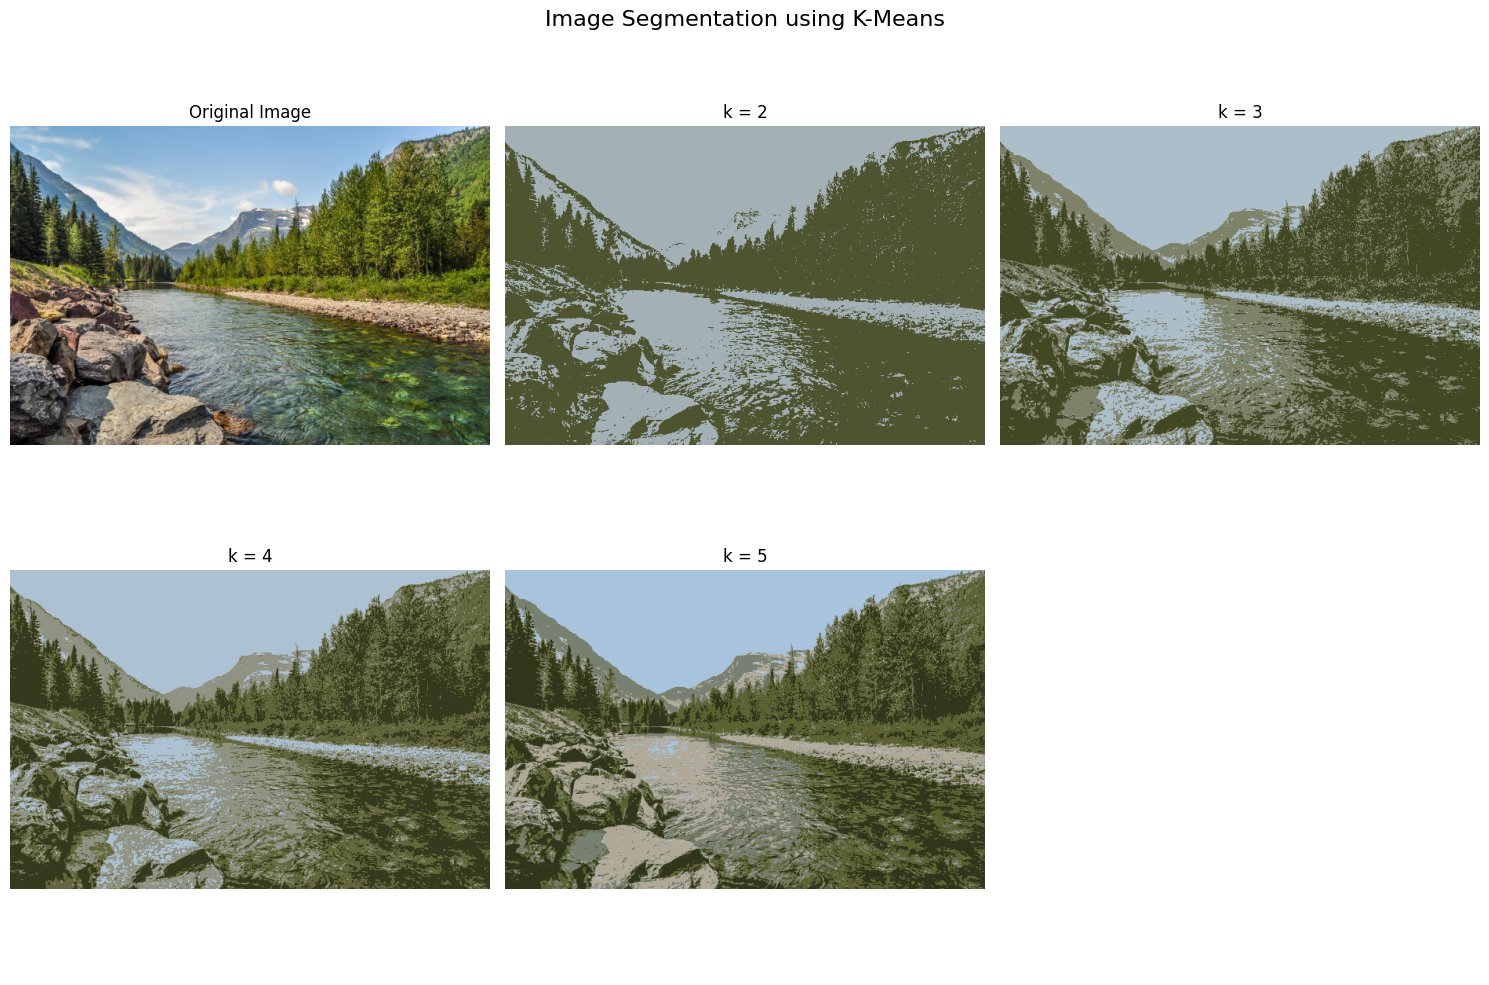

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Image Segmentation using K-Means", fontsize=16)

axes[0, 0].imshow(image_array)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

for idx, (k, img) in enumerate(zip(k_values, segmented_images)):
    r = (idx + 1) // 3
    c = (idx + 1) % 3
    axes[r, c].imshow(img)
    axes[r, c].set_title(f"k = {k}")
    axes[r, c].axis("off")

axes[1, 2].axis("off")
plt.tight_layout()
plt.show()
